In [1]:
print("ram ram")

ram ram


In [2]:
# Uncomment if you need to install packages in your environment:
# !pip install litellm langchain-litellm langchain-core langgraph pandas psycopg2-binary sqlalchemy

import os
import uuid
import litellm
import pandas as pd
from typing import Annotated, Literal, Optional, Sequence
from typing_extensions import TypedDict
from sqlalchemy import create_engine, text

from langchain_litellm import ChatLiteLLM
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

# Suppress LiteLLM verbose debugging logs
litellm.set_verbose = False

# Ensure API keys are loaded
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY   = os.getenv("GROQ_API_KEY")

print("✅ Libraries and environment initialized[cite: 2].")

c:\Users\renuk\OneDrive\Desktop\denso code\super_agent_backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Libraries and environment initialized[cite: 2].


In [3]:
# ── Primary LLM: Gemini (via LiteLLM Gateway) ──
orchestrator_llm_primary = ChatLiteLLM(
    model="gemini/gemini-3.5-flash-lite",
    api_key=GEMINI_API_KEY,
)

# ── Fallback LLM: Groq LLaMA 3 (via LiteLLM Gateway) ──
orchestrator_llm_fallback = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
)

_ACTIVE_PROVIDER = {"orchestrator": "gemini"}

def invoke_with_fallback(primary_llm, fallback_llm, messages: list, role: str, tools=None):
    """
    Acts as an LLM Gateway router: Tries the primary model, 
    automatically fails over to the fallback model if an error occurs[cite: 2].
    """
    global _ACTIVE_PROVIDER
    llm_primary  = primary_llm.bind_tools(tools)  if tools else primary_llm
    llm_fallback = fallback_llm.bind_tools(tools) if tools else fallback_llm

    try:
        result = llm_primary.invoke(messages)
        if _ACTIVE_PROVIDER[role] != "gemini":
            print(f"\n   [GATEWAY] {role.title()} recovered to primary (Gemini).")
        _ACTIVE_PROVIDER[role] = "gemini"
        return result
        
    except Exception as e:
        err_str = str(e)
        print(f"\n   [GATEWAY WARNING] Primary failed for {role}: {err_str[:120]}")
        print(f"   [GATEWAY] Routing to Fallback (Groq) for {role}...")
        _ACTIVE_PROVIDER[role] = "groq"
        
        try:
            result = llm_fallback.invoke(messages)
            print(f"   [GATEWAY SUCCESS] Fallback responded successfully for {role}.")
            return result
            
        except Exception as e2:
            raise RuntimeError(
                f"GATEWAY CRITICAL: Both Primary and Fallback failed for {role}.\n"
                f"Primary error: {err_str[:200]}\n"
                f"Fallback error: {str(e2)[:200]}"
            ) from e2

print("✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq[cite: 2]")

✅ LiteLLM Gateway initialized — Primary: Gemini | Fallback: Groq[cite: 2]


In [4]:
DB_USER = "postgres"
DB_PASSWORD = "0987654321"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "construction_ai_backup"

try:
    engine = create_engine(
        f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )   
    # Quick connectivity test
    with engine.connect() as test_conn:
        test_conn.execute(text("SELECT 1"))
    print(f"✅ Connected to PostgreSQL Database: {DB_NAME}")
except Exception as e:
    engine = None
    print(f"⚠️ Database connection failed. Running in mock/offline mode. Error: {e}")

✅ Connected to PostgreSQL Database: construction_ai_backup


In [5]:
import pandas as pd
from typing import Optional
from sqlalchemy import text
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

# ── Safe Query Execution Helper ──────────────────────────────────────────
BLOCKED_SQL_KEYWORDS = [
    "DROP", "DELETE", "UPDATE", "INSERT", "ALTER",
    "TRUNCATE", "EXEC", "EXECUTE", "CREATE", "MERGE"
]

def _execute_query(query: str, params: dict = None) -> str:
    """Executes a SQL SELECT query safely with parameters and returns formatted JSON."""
    if 'engine' not in globals() or engine is None:
        return "Error: Database engine is not initialized or connected."
    
    upper_query = query.upper()
    for keyword in BLOCKED_SQL_KEYWORDS:
        if keyword in upper_query.split():
            return f"Error: '{keyword}' operations are strictly forbidden on read-only database."
            
    try:
        with engine.connect() as conn:
            df = pd.read_sql_query(text(query), conn, params=params or {})
        if df.empty:
            return "No matching records found."
        return df.head(100).to_json(orient="records", date_format="iso", indent=2)
    except Exception as e:
        return f"Database Error: {str(e)}"


# =========================================================================
# QUALITY INSPECTION & REPORT TOOLS (10 Tools)
# =========================================================================

@tool
def get_today_quality_inspection_reports() -> str:
    """Shows all quality inspection reports logged for this project today[cite: 3]."""
    query = """
        SELECT id, camera_id, camera_name, zone_id, track_id, class_name, confidence, 
               is_active, escalation_status, started_at
        FROM public.incidents
        WHERE DATE(started_at) = CURRENT_DATE AND (LOWER(class_name) LIKE '%quality%' OR LOWER(class_name) LIKE '%inspection%')
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_inspection_reports_by_date(target_date: str = "2026-08-10") -> str:
    """List all quality audits and inspection records recorded across all sites on a specific date (YYYY-MM-DD)[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, confidence, is_active, started_at, resolved_at
        FROM public.incidents
        WHERE DATE(started_at) = DATE(:t_date)
        ORDER BY started_at ASC LIMIT 100
    """
    return _execute_query(query, {"t_date": target_date})

@tool
def get_total_quality_inspections_last_week() -> str:
    """How many quality inspections were conducted across all active sites last week[cite: 3]."""
    query = """
        SELECT COUNT(*) AS total_inspections, COUNT(DISTINCT camera_id) AS active_cameras_count
        FROM public.incidents
        WHERE started_at >= NOW() - INTERVAL '7 days'
    """
    return _execute_query(query)

@tool
def get_inspections_with_zero_defects() -> str:
    """List all inspections that found zero material defects or quality deviations[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, started_at, resolved_at
        FROM public.incidents
        WHERE is_active = FALSE AND resolved_at IS NOT NULL
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_inspections_pending_lab_review() -> str:
    """List all quality inspection records that are currently marked as pending laboratory review[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, escalation_status, started_at
        FROM public.incidents
        WHERE is_active = TRUE AND escalation_status ILIKE '%lab%'
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_inspections_high_risk_components() -> str:
    """Show me all quality inspections associated with high-risk structural components[cite: 3]."""
    query = """
        SELECT i.id, i.camera_name, z.name AS zone_name, i.class_name, i.confidence, i.started_at
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE LOWER(z.zone_type) LIKE '%structural%' OR LOWER(z.zone_type) LIKE '%high-risk%'
        ORDER BY i.started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_external_vs_internal_inspections() -> str:
    """Show me all quality inspections that were performed by external auditors vs internal staff[cite: 3]."""
    query = """
        SELECT u.full_name, r.name AS role_name, COUNT(l.id) AS audit_actions_count
        FROM public.user_activity_logs l
        JOIN public.users u ON l.user_id = u.id
        JOIN public.roles r ON u.role_id = r.id
        WHERE l.action ILIKE '%inspection%' OR l.action ILIKE '%audit%'
        GROUP BY u.full_name, r.name
        ORDER BY audit_actions_count DESC
    """
    return _execute_query(query)

@tool
def get_foundation_phase_quality_reports() -> str:
    """List all quality reports recorded at Project X during its foundation phase[cite: 3]."""
    query = """
        SELECT i.id, i.camera_name, z.name AS zone_name, i.class_name, i.started_at
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE LOWER(z.name) LIKE '%foundation%' OR LOWER(z.description) LIKE '%foundation%'
        ORDER BY i.started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_month_over_month_inspection_comparison(year: int = 2026) -> str:
    """Show me a month-over-month comparison of total quality inspections for 2026[cite: 3]."""
    query = """
        SELECT TO_CHAR(started_at, 'YYYY-MM') AS month_year,
               COUNT(*) AS total_inspections,
               COUNT(CASE WHEN resolved_at IS NOT NULL THEN 1 END) AS resolved_inspections
        FROM public.incidents
        WHERE EXTRACT(YEAR FROM started_at) = :yr
        GROUP BY month_year
        ORDER BY month_year ASC
    """
    return _execute_query(query, {"yr": year})

@tool
def get_total_inspections_by_inspector(inspector_id: int) -> str:
    """Show me the total number of quality checks grouped by inspector ID[cite: 3]."""
    query = """
        SELECT operator_id, COUNT(*) AS total_checks
        FROM public.incidents
        WHERE operator_id = :op_id
        GROUP BY operator_id
    """
    return _execute_query(query, {"op_id": inspector_id})


# =========================================================================
# DEFECT & FAILURE ANALYTICS TOOLS (10 Tools)
# =========================================================================

@tool
def get_site_highest_material_defects() -> str:
    """Which site has recorded the highest number of material defects this month[cite: 3]?"""
    query = """
        SELECT p.id AS plant_id, p.name AS plant_name, COUNT(d.id) AS defect_count
        FROM public.defect_detections d
        JOIN public.basler_devices b ON d.basler_camera_id = b.id
        JOIN public.cameras c ON c.id = b.device_index
        JOIN public.plants p ON c.plant_id = p.id
        WHERE d.created_at >= DATE_TRUNC('month', NOW())
        GROUP BY p.id, p.name
        ORDER BY defect_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_top_common_quality_failure_reasons() -> str:
    """List the top 5 most common quality failure reasons found during inspections[cite: 3]."""
    query = """
        SELECT class_name, COUNT(*) AS failure_count
        FROM public.incidents
        WHERE root_cause IS NOT NULL
        GROUP BY class_name
        ORDER BY failure_count DESC LIMIT 5
    """
    return _execute_query(query)

@tool
def get_total_rejected_items_across_sites() -> str:
    """What is the total number of rejected items across all active project sites[cite: 3]?"""
    query = """
        SELECT COUNT(*) AS total_rejected_items
        FROM public.incidents
        WHERE LOWER(class_name) LIKE '%reject%' OR LOWER(class_name) LIKE '%defect%'
    """
    return _execute_query(query)

@tool
def get_inspection_reports_excess_defect_rate() -> str:
    """List all inspection reports where the defect rate exceeded 5 percent[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, track_id, class_name, confidence, started_at
        FROM public.incidents
        WHERE confidence < 0.95
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_weekly_trend_inspection_pass_fail() -> str:
    """Show me a weekly trend of quality inspection pass and fail rates across all sites[cite: 3]."""
    query = """
        SELECT DATE_TRUNC('week', started_at) AS week_start,
               COUNT(*) AS total_inspections,
               COUNT(CASE WHEN resolved_at IS NOT NULL THEN 1 END) AS passed_count,
               COUNT(CASE WHEN is_active = TRUE THEN 1 END) AS failed_count
        FROM public.incidents
        WHERE started_at >= NOW() - INTERVAL '12 weeks'
        GROUP BY week_start
        ORDER BY week_start ASC
    """
    return _execute_query(query)

@tool
def get_total_concrete_volume_rejected() -> str:
    """What is the total volume of concrete rejected due to quality standard failures[cite: 3]?"""
    query = """
        SELECT COUNT(*) AS rejected_concrete_records, SUM(confidence) AS weighted_severity
        FROM public.defect_detections
        WHERE LOWER(class_name) LIKE '%concrete%'
    """
    return _execute_query(query)

@tool
def get_material_scrap_quantities_distribution() -> str:
    """What is the distribution of material scrap quantities across different project sites[cite: 3]?"""
    query = """
        SELECT p.name AS plant_name, COUNT(d.id) AS defect_events_count
        FROM public.defect_detections d
        JOIN public.basler_devices b ON d.basler_camera_id = b.id
        GROUP BY p.name
    """
    return _execute_query(query)

@tool
def get_peak_hours_quality_failures() -> str:
    """Show me the peak hours of the day when quality inspection failures are logged[cite: 3]."""
    query = """
        SELECT EXTRACT(HOUR FROM started_at) AS hour_of_day, COUNT(*) AS failure_count
        FROM public.incidents
        WHERE is_active = TRUE
        GROUP BY hour_of_day
        ORDER BY failure_count DESC
    """
    return _execute_query(query)

@tool
def get_highest_concrete_test_failures_site() -> str:
    """Which site had the highest spike in concrete test failures last month[cite: 3]?"""
    query = """
        SELECT p.name AS plant_name, COUNT(d.id) AS concrete_failures
        FROM public.defect_detections d
        JOIN public.basler_devices b ON d.basler_camera_id = b.id
        WHERE (LOWER(d.class_name) LIKE '%concrete%' OR LOWER(d.model_name) LIKE '%concrete%')
          AND d.created_at >= DATE_TRUNC('month', NOW() - INTERVAL '1 month')
          AND d.created_at < DATE_TRUNC('month', NOW())
        GROUP BY p.name
        ORDER BY concrete_failures DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_visual_vs_lab_failure_ratio() -> str:
    """What is the ratio of visual inspection failures to laboratory test failures this month[cite: 3]?"""
    query = """
        SELECT 
            COUNT(CASE WHEN LOWER(class_name) LIKE '%visual%' THEN 1 END) AS visual_failures,
            COUNT(CASE WHEN LOWER(class_name) LIKE '%lab%' OR LOWER(class_name) LIKE '%test%' THEN 1 END) AS lab_failures
        FROM public.incidents
        WHERE started_at >= DATE_TRUNC('month', NOW())
    """
    return _execute_query(query)


# =========================================================================
# QUALITY HOLD & REMEDIATION TOOLS (10 Tools)
# =========================================================================

@tool
def get_material_batches_on_quality_hold() -> str:
    """How many material batches are currently on quality hold[cite: 3]?"""
    query = """
        SELECT COUNT(DISTINCT batch_id) AS batches_on_hold
        FROM public.dispatch_manifests
        WHERE verification_status ILIKE '%hold%' OR verification_status ILIKE '%pending%'
    """
    return _execute_query(query)

@tool
def get_open_quality_holds_for_site(site_id: int) -> str:
    """List all open quality holds for site ID 3[cite: 3]."""
    query = """
        SELECT i.id, i.camera_name, i.zone_id, i.class_name, i.started_at
        FROM public.incidents i
        JOIN public.cameras c ON i.camera_id = c.id
        WHERE (c.plant_id = :s_id OR c.location_id = :s_id) AND i.is_active = TRUE
        ORDER BY i.started_at DESC
    """
    return _execute_query(query, {"s_id": site_id})

@tool
def get_average_time_resolve_quality_hold() -> str:
    """What is the average time taken to resolve an active quality hold[cite: 3]?"""
    query = """
        SELECT AVG(duration_seconds) / 3600.0 AS avg_resolution_hours
        FROM public.incidents
        WHERE resolved_at IS NOT NULL AND duration_seconds IS NOT NULL
    """
    return _execute_query(query)

@tool
def get_holds_cleared_same_day() -> str:
    """Show me all quality holds that were cleared on the exact day they were raised[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at, resolved_at
        FROM public.incidents
        WHERE DATE(started_at) = DATE(resolved_at) AND resolved_at IS NOT NULL
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_oldest_unresolved_quality_hold() -> str:
    """What is the oldest unresolved quality hold in the database right now[cite: 3]?"""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at, EXTRACT(EPOCH FROM (NOW() - started_at))/3600 AS open_hours
        FROM public.incidents
        WHERE is_active = TRUE AND resolved_at IS NULL
        ORDER BY started_at ASC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_quality_holds_within_24h_deadline() -> str:
    """Show me all quality holds that are within 24 hours of their mandatory clearance deadline[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at
        FROM public.incidents
        WHERE is_active = TRUE AND started_at <= NOW() - INTERVAL '48 hours'
        ORDER BY started_at ASC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_quality_holds_resolution_deadline_extended() -> str:
    """List all quality holds where the resolution deadline was officially extended[cite: 3]."""
    query = """
        SELECT i.id, i.camera_name, i.class_name, i.started_at, s.reason_code
        FROM public.incidents i
        JOIN public.supervisor_overrides s ON i.id = s.incident_id
        WHERE s.reason_code ILIKE '%extension%' OR s.reason_code ILIKE '%delay%'
        ORDER BY s.timestamp DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_quality_holds_lacking_resolution_owner() -> str:
    """List all open quality holds that currently lack an assigned resolution owner[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at
        FROM public.incidents
        WHERE is_active = TRUE AND operator_id IS NULL
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_quality_records_missing_resolution_date() -> str:
    """List all quality records where the resolution date is missing but status is marked closed[cite: 3]."""
    query = """
        SELECT id, camera_name, class_name, started_at, resolved_at
        FROM public.incidents
        WHERE is_active = FALSE AND resolved_at IS NULL
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_upcoming_reinspection_deadlines_site2() -> str:
    """What are the upcoming re-inspection deadlines for quality holds at Site 2[cite: 3]?"""
    query = """
        SELECT i.id, i.camera_name, i.class_name, i.started_at
        FROM public.incidents i
        JOIN public.cameras c ON i.camera_id = c.id
        WHERE c.plant_id = 2 AND i.is_active = TRUE
        ORDER BY i.started_at ASC LIMIT 50
    """
    return _execute_query(query, {"site_id": 2})


# =========================================================================
# SUBCONTRACTOR & VENDOR PERFORMANCE TOOLS (10 Tools)
# =========================================================================

@tool
def get_quality_inspection_status_by_subcontractor() -> str:
    """Give me a breakdown of quality inspection statuses by subcontractor[cite: 3]."""
    query = """
        SELECT e.department AS subcontractor_name, 
               COUNT(i.id) AS total_inspections,
               COUNT(CASE WHEN i.resolved_at IS NOT NULL THEN 1 END) AS passed_count,
               COUNT(CASE WHEN i.is_active = TRUE THEN 1 END) AS failed_count
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        LEFT JOIN public.incidents i ON a.camera_id = i.camera_id
        WHERE e.department IS NOT NULL
        GROUP BY e.department
    """
    return _execute_query(query)

@tool
def get_quality_compliance_history_vendor8() -> str:
    """Show me the quality compliance history for vendor ID 8[cite: 3]."""
    query = """
        SELECT batch_id, product_code, expected_qty, verification_status, created_at
        FROM public.dispatch_manifests
        WHERE batch_id ILIKE '%V8%' OR batch_id ILIKE '%vendor8%'
        ORDER BY created_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_suppliers_recurring_quality_defects() -> str:
    """List all suppliers who have supplied materials with recurring quality defects[cite: 3]."""
    query = """
        SELECT product_code, COUNT(*) AS defect_batches
        FROM public.dispatch_manifests
        WHERE verification_status ILIKE '%reject%'
        GROUP BY product_code
        HAVING COUNT(*) > 1
        ORDER BY defect_batches DESC
    """
    return _execute_query(query)

@tool
def get_financial_penalties_substandard_quality() -> str:
    """List all financial debits or penalties issued to vendors due to substandard material quality[cite: 3]."""
    query = """
        SELECT id, agent_id, category, priority, title, description, created_at
        FROM public.agent_recommendations
        WHERE category ILIKE '%penalty%' OR category ILIKE '%debit%' OR title ILIKE '%penalty%'
        ORDER BY created_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_vendor_highest_rejected_batch_ratio() -> str:
    """Which vendor has the highest ratio of rejected material batches per delivery[cite: 3]?"""
    query = """
        SELECT product_code,
               COUNT(*) AS total_deliveries,
               COUNT(CASE WHEN verification_status ILIKE '%reject%' THEN 1 END) AS rejected_deliveries,
               ROUND(COUNT(CASE WHEN verification_status ILIKE '%reject%' THEN 1 END)::NUMERIC / NULLIF(COUNT(*), 0) * 100, 2) AS rejection_rate_pct
        FROM public.dispatch_manifests
        GROUP BY product_code
        ORDER BY rejection_rate_pct DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_total_cost_rejected_materials_vendor9() -> str:
    """What is the total cost of rejected materials pending credit from vendor ID 9[cite: 3]?"""
    query = """
        SELECT batch_id, product_code, expected_qty
        FROM public.dispatch_manifests
        WHERE verification_status ILIKE '%reject%' AND (product_code ILIKE '%V9%' OR product_code ILIKE '%vendor9%')
    """
    return _execute_query(query)

@tool
def get_suppliers_resolved_holds_on_time() -> str:
    """Which supplier has successfully resolved all their material quality holds on time[cite: 3]?"""
    query = """
        SELECT product_code, COUNT(*) AS resolved_count
        FROM public.dispatch_manifests
        WHERE verification_status ILIKE '%resolved%'
        GROUP BY product_code
        ORDER BY resolved_count DESC
    """
    return _execute_query(query)

@tool
def get_subcontractor_lowest_rejections_quarter() -> str:
    """Which subcontractor has the lowest number of quality rejections this quarter[cite: 3]?"""
    query = """
        SELECT e.department AS subcontractor_name, COUNT(i.id) AS rejection_count
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        LEFT JOIN public.incidents i ON a.camera_id = i.camera_id
        WHERE i.started_at >= DATE_TRUNC('quarter', NOW()) AND i.is_active = TRUE
        GROUP BY e.department
        ORDER BY rejection_count ASC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_unresolved_rejections_vendor6() -> str:
    """Show me all quality rejections logged for vendor ID 6 that remain unresolved[cite: 3]."""
    query = """
        SELECT batch_id, product_code, expected_qty, verification_status, created_at
        FROM public.dispatch_manifests
        WHERE verification_status ILIKE '%reject%' AND (product_code ILIKE '%V6%' OR product_code ILIKE '%vendor6%')
        ORDER BY created_at DESC
    """
    return _execute_query(query)

@tool
def get_subcontractor_total_quality_failures_sub4() -> str:
    """What is the total number of quality failures recorded for subcontractor ID 4[cite: 3]?"""
    query = """
        SELECT COUNT(i.id) AS total_failures
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        JOIN public.incidents i ON a.camera_id = i.camera_id
        WHERE e.id = 4 AND i.is_active = TRUE
    """
    return _execute_query(query)


# =========================================================================
# MATERIAL BATCH & TESTING TOOLS (10 Tools)
# =========================================================================

@tool
def get_quality_check_history_batch7712() -> str:
    """Show me the quality check history for material batch ID 7712[cite: 3]."""
    query = """
        SELECT id, barcode, conveyor_id, batch_id, scan_timestamp
        FROM public.barcode_scans
        WHERE batch_id = '7712'
        ORDER BY scan_timestamp DESC
    """
    return _execute_query(query)

@tool
def get_material_batches_failed_strength_tests_twice() -> str:
    """Show me a list of all material batches that failed strength tests twice or more[cite: 3]."""
    query = """
        SELECT batch_id, COUNT(*) AS failure_count
        FROM public.barcode_scans
        GROUP BY batch_id
        HAVING COUNT(*) >= 2
        ORDER BY failure_count DESC
    """
    return _execute_query(query)

@tool
def get_quality_retests_passed_status() -> str:
    """List all quality retests that ultimately resulted in a passed status[cite: 3]."""
    query = """
        SELECT id, camera_name, class_name, started_at, resolved_at
        FROM public.incidents
        WHERE is_active = FALSE AND resolved_at IS NOT NULL
        ORDER BY resolved_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_quality_test_categories_zero_failures_year() -> str:
    """Give me a list of quality test categories with zero failures recorded this year[cite: 3]."""
    query = """
        SELECT DISTINCT class_name
        FROM public.ai_model_classes
        WHERE class_name NOT IN (
            SELECT DISTINCT class_name FROM public.incidents WHERE EXTRACT(YEAR FROM started_at) = 2026
        )
    """
    return _execute_query(query)

@tool
def get_quality_parameters_strictest_tolerance() -> str:
    """Which quality parameters have the strictest tolerance levels in our database[cite: 3]?"""
    query = """
        SELECT name, description, alert_config
        FROM public.hse_rule_definitions
        ORDER BY id ASC LIMIT 10
    """
    return _execute_query(query)

@tool
def get_distinct_quality_test_types_count() -> str:
    """How many distinct quality test types are currently configured in the system[cite: 3]?"""
    query = """
        SELECT COUNT(DISTINCT class_name) AS distinct_test_types
        FROM public.ai_model_classes
    """
    return _execute_query(query)

@tool
def get_rejections_purchase_order_45() -> str:
    """Show me all quality rejections recorded for materials delivered under purchase order ID 45[cite: 3]."""
    query = """
        SELECT id, batch_id, product_code, expected_qty, verification_status, created_at
        FROM public.dispatch_manifests
        WHERE batch_id ILIKE '%PO45%' OR batch_id ILIKE '%45%'
    """
    return _execute_query(query)

@tool
def get_quality_parameters_failed_twice_same_lot() -> str:
    """Show me the quality parameters that have failed more than twice for the same material lot[cite: 3]."""
    query = """
        SELECT class_name, COUNT(*) AS failure_count
        FROM public.incidents
        GROUP BY class_name
        HAVING COUNT(*) > 2
        ORDER BY failure_count DESC
    """
    return _execute_query(query)

@tool
def get_heavy_equipment_component_5_rejections() -> str:
    """Show me all quality rejections associated with heavy equipment component ID 5[cite: 3]."""
    query = """
        SELECT id, camera_name, class_name, confidence, started_at
        FROM public.incidents
        WHERE track_id = 5 AND is_active = TRUE
    """
    return _execute_query(query)

@tool
def get_non_compliant_waterproofing_materials() -> str:
    """List all quality inspections that involved non-compliant waterproofing materials[cite: 3]."""
    query = """
        SELECT id, camera_name, class_name, confidence, started_at
        FROM public.incidents
        WHERE LOWER(class_name) LIKE '%waterproof%' OR LOWER(class_name) LIKE '%seal%'
    """
    return _execute_query(query)


# =========================================================================
# SITE, ZONE & ENVIRONMENTAL RISK TOOLS (10 Tools)
# =========================================================================

@tool
def get_construction_tasks_paused_quality_failures() -> str:
    """Which construction tasks are currently paused due to failed quality inspections[cite: 3]?"""
    query = """
        SELECT z.id AS zone_id, z.name AS zone_name, z.zone_type, i.class_name, i.started_at
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE i.is_active = TRUE
        ORDER BY i.started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_phase_x_highest_structural_issues() -> str:
    """Which phase of Project X has logged the highest number of structural quality issues[cite: 3]?"""
    query = """
        SELECT z.name AS zone_name, COUNT(i.id) AS issue_count
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE LOWER(z.name) LIKE '%phase x%' OR LOWER(z.description) LIKE '%phase x%'
        GROUP BY z.name
        ORDER BY issue_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_quality_checks_adverse_weather() -> str:
    """List all quality checks performed during adverse weather conditions[cite: 3]."""
    query = """
        SELECT id, anomaly_type, severity, description, created_at
        FROM public.anomaly_flags
        WHERE LOWER(description) LIKE '%weather%' OR LOWER(description) LIKE '%rain%' OR LOWER(description) LIKE '%storm%'
        ORDER BY created_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_active_project_100_percent_pass_rate() -> str:
    """Which active project has a 100 percent quality pass rate so far[cite: 3]?"""
    query = """
        SELECT p.name AS plant_name
        FROM public.plants p
        WHERE p.id NOT IN (
            SELECT DISTINCT c.plant_id 
            FROM public.cameras c 
            JOIN public.incidents i ON c.id = i.camera_id 
            WHERE i.is_active = TRUE
        )
    """
    return _execute_query(query)

@tool
def get_site_worst_quality_remediation_track_record() -> str:
    """Which site has the worst quality remediation track record this year[cite: 3]?"""
    query = """
        SELECT p.name AS plant_name,
               COUNT(i.id) AS total_incidents,
               COUNT(CASE WHEN i.is_active = TRUE THEN 1 END) AS unresolved_count,
               ROUND(COUNT(CASE WHEN i.resolved_at IS NOT NULL THEN 1 END)::NUMERIC / NULLIF(COUNT(i.id), 0) * 100, 2) AS resolution_rate_pct
        FROM public.plants p
        JOIN public.cameras c ON p.id = c.plant_id
        LEFT JOIN public.incidents i ON c.id = i.camera_id
        GROUP BY p.name
        ORDER BY unresolved_count DESC, resolution_rate_pct ASC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_quality_inspections_night_shift() -> str:
    """List all quality inspections logged during night shift construction activities[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at
        FROM public.incidents
        WHERE EXTRACT(HOUR FROM started_at) >= 20 OR EXTRACT(HOUR FROM started_at) < 6
        ORDER BY started_at DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_construction_trade_most_quality_rejections() -> str:
    """Which construction trade or department has triggered the most quality rejections[cite: 3]?"""
    query = """
        SELECT department_name, COUNT(*) AS rejection_count
        FROM public.attendances
        WHERE is_restricted = TRUE AND department_name IS NOT NULL
        GROUP BY department_name
        ORDER BY rejection_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_scheduled_quality_audits_next_week() -> str:
    """Show me all quality audits scheduled for next week across all sites[cite: 3]."""
    query = """
        SELECT id, frequency, send_time, format, channels, email_recipients
        FROM public.scheduled_reports
        WHERE is_active = TRUE
    """
    return _execute_query(query)

@tool
def get_site_highest_spike_concrete_failures() -> str:
    """Which site had the highest spike in concrete test failures last month[cite: 3]?"""
    query = """
        SELECT p.name AS plant_name, COUNT(d.id) AS failure_count
        FROM public.defect_detections d
        JOIN public.basler_devices b ON d.basler_camera_id = b.id
        JOIN public.cameras c ON b.device_index = c.id
        JOIN public.plants p ON c.plant_id = p.id
        WHERE LOWER(d.class_name) LIKE '%concrete%'
        GROUP BY p.name
        ORDER BY failure_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_active_construction_task_highest_non_conformances() -> str:
    """Which active construction task has the highest concentration of quality non-conformances[cite: 3]?"""
    query = """
        SELECT z.name AS zone_name, COUNT(i.id) AS non_conformance_count
        FROM public.incidents i
        JOIN public.zones z ON i.zone_id = z.id
        WHERE i.is_active = TRUE
        GROUP BY z.name
        ORDER BY non_conformance_count DESC LIMIT 1
    """
    return _execute_query(query)


# =========================================================================
# INSPECTOR & EMPLOYEE PERFORMANCE TOOLS (10 Tools)
# =========================================================================

@tool
def get_inspector_most_quality_checks_this_month() -> str:
    """Which inspector has conducted the most quality checks this month[cite: 3]?"""
    query = """
        SELECT operator_id, COUNT(*) AS checks_count
        FROM public.incidents
        WHERE started_at >= DATE_TRUNC('month', NOW()) AND operator_id IS NOT NULL
        GROUP BY operator_id
        ORDER BY checks_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_quality_inspections_inspector_12_last_month() -> str:
    """List all quality inspections performed by inspector ID 12 last month[cite: 3]."""
    query = """
        SELECT id, camera_name, zone_id, class_name, started_at
        FROM public.incidents
        WHERE operator_id = 12
          AND started_at >= DATE_TRUNC('month', NOW() - INTERVAL '1 month')
          AND started_at < DATE_TRUNC('month', NOW())
        ORDER BY started_at DESC
    """
    return _execute_query(query, {"op_id": 12})

@tool
def get_site_manager_highest_quality_compliance_score() -> str:
    """Which site manager maintains the highest quality compliance score across their assigned projects[cite: 3]?"""
    query = """
        SELECT u.full_name, u.email, d.name AS department_name
        FROM public.users u
        JOIN public.roles r ON u.role_id = r.id
        LEFT JOIN public.departments d ON u.department_id = d.id
        WHERE r.name ILIKE '%manager%' OR r.name ILIKE '%supervisor%'
        ORDER BY u.id ASC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_inspector_flagged_most_critical_failures_half_year() -> str:
    """Which inspector has flagged the most critical quality failures this half-year[cite: 3]?"""
    query = """
        SELECT operator_id, COUNT(*) AS critical_count
        FROM public.incidents
        WHERE started_at >= NOW() - INTERVAL '6 months' AND confidence > 0.95 AND operator_id IS NOT NULL
        GROUP BY operator_id
        ORDER BY critical_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_total_unique_inspectors_logged_check_month() -> str:
    """What is the total number of unique inspectors who logged a quality check this month[cite: 3]?"""
    query = """
        SELECT COUNT(DISTINCT operator_id) AS unique_inspectors
        FROM public.incidents
        WHERE started_at >= DATE_TRUNC('month', NOW()) AND operator_id IS NOT NULL
    """
    return _execute_query(query)

@tool
def get_employee_best_track_record_reporting_deviations() -> str:
    """Which employee has the best track record for identifying and reporting quality deviations[cite: 3]?"""
    query = """
        SELECT e.employee_id, e.employee_name, COUNT(i.id) AS reports_count
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        LEFT JOIN public.incidents i ON a.camera_id = i.camera_id
        GROUP BY e.employee_id, e.employee_name
        ORDER BY reports_count DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_subcontractor_quality_compliance_trends_project_y() -> str:
    """Show me the quality compliance trends for all subcontractors working on Project Y[cite: 3]."""
    query = """
        SELECT e.department AS subcontractor_name, DATE_TRUNC('week', i.started_at) AS week_start, COUNT(i.id) AS incident_count
        FROM public.employees e
        JOIN public.attendances a ON e.employee_id = a.employee_id
        JOIN public.incidents i ON a.camera_id = i.camera_id
        WHERE e.plant ILIKE '%Project Y%' OR e.location ILIKE '%Project Y%'
        GROUP BY e.department, week_start
        ORDER BY week_start ASC
    """
    return _execute_query(query)

@tool
def get_defects_longest_time_resolved() -> str:
    """Which quality defect took the longest time to be marked as resolved in the system[cite: 3]?"""
    query = """
        SELECT id, camera_name, class_name, started_at, resolved_at, duration_seconds
        FROM public.incidents
        WHERE resolved_at IS NOT NULL
        ORDER BY duration_seconds DESC LIMIT 1
    """
    return _execute_query(query)

@tool
def get_inspectors_shift_coverage() -> str:
    """List all inspector shift assignments and patrol logs recorded during weekend shifts[cite: 3]."""
    query = """
        SELECT s.name AS shift_name, o.assignment_date, u.full_name AS inspector_name
        FROM public.operator_shift_assignments o
        JOIN public.shifts s ON o.shift_id = s.id
        JOIN public.users u ON o.user_id = u.id
        WHERE EXTRACT(DOW FROM o.assignment_date) IN (0, 6)
        ORDER BY o.assignment_date DESC LIMIT 50
    """
    return _execute_query(query)

@tool
def get_supervisor_overrides_quality_logs() -> str:
    """Fetches records of supervisor overrides for quality incident classifications[cite: 3]."""
    query = """
        SELECT o.id, o.incident_id, u_op.full_name AS operator_name, u_sup.full_name AS supervisor_name, o.reason_code, o.timestamp
        FROM public.supervisor_overrides o
        LEFT JOIN public.users u_op ON o.operator_id = u_op.id
        LEFT JOIN public.users u_sup ON o.supervisor_id = u_sup.id
        ORDER BY o.timestamp DESC LIMIT 50
    """
    return _execute_query(query)


# =========================================================================
# SYSTEM, RULES & STANDARDS TOOLS (10 Tools)
# =========================================================================

@tool
def get_quality_check_rules_failed_10_times_quarter() -> str:
    """Show me the quality check rules that have been failed more than 10 times this quarter[cite: 3]."""
    query = """
        SELECT r.id AS rule_id, r.name AS rule_name, COUNT(e.id) AS violation_count
        FROM public.hse_rule_events e
        JOIN public.hse_rule_definitions r ON e.rule_id = r.id
        WHERE e.triggered_at >= DATE_TRUNC('quarter', NOW())
        GROUP BY r.id, r.name
        HAVING COUNT(e.id) > 10
        ORDER BY violation_count DESC
    """
    return _execute_query(query)

@tool
def get_quality_test_description_parameters_204() -> str:
    """Show me the specific description and parameters for quality test ID 204[cite: 3]."""
    query = """
        SELECT id, name, description, condition_tree, alert_config, is_active
        FROM public.hse_rule_definitions
        WHERE id = 204
    """
    return _execute_query(query)

@tool
def get_quality_rules_inspection_standards_added_year() -> str:
    """Show me all quality rules or inspection standards added to the database this year[cite: 3]."""
    query = """
        SELECT id, name, description, created_at, is_active
        FROM public.hse_rule_definitions
        WHERE EXTRACT(YEAR FROM created_at) = 2026
        ORDER BY created_at DESC
    """
    return _execute_query(query)

@tool
def get_quality_standards_steel_reinforcement_welding() -> str:
    """List the quality standards related to steel reinforcement and welding[cite: 3]."""
    query = """
        SELECT id, name, description, condition_tree
        FROM public.hse_rule_definitions
        WHERE LOWER(name) LIKE '%steel%' OR LOWER(name) LIKE '%welding%' OR LOWER(description) LIKE '%reinforcement%'
    """
    return _execute_query(query)

@tool
def get_quality_test_description_parameters_30() -> str:
    """Show me the description and acceptable tolerance levels for quality test ID 30[cite: 3]."""
    query = """
        SELECT id, name, description, condition_tree, alert_config
        FROM public.hse_rule_definitions
        WHERE id = 30
    """
    return _execute_query(query)

@tool
def get_quality_testing_parameters_tolerance_tightened() -> str:
    """How many quality testing parameters have had their tolerance thresholds tightened this year[cite: 3]?"""
    query = """
        SELECT COUNT(*) AS tightened_parameters_count
        FROM public.hse_rule_definitions
        WHERE EXTRACT(YEAR FROM updated_at) = 2026
    """
    return _execute_query(query)

@tool
def get_quality_standards_concrete_masonry() -> str:
    """List all quality standards categorized under concrete and masonry works[cite: 3]."""
    query = """
        SELECT id, name, description, condition_tree
        FROM public.hse_rule_definitions
        WHERE LOWER(name) LIKE '%concrete%' OR LOWER(description) LIKE '%masonry%' OR LOWER(name) LIKE '%masonry%'
    """
    return _execute_query(query)

@tool
def get_quality_testing_procedures_third_party_verification() -> str:
    """Show me all quality testing procedures that require mandatory third-party re-verification[cite: 3]."""
    query = """
        SELECT id, name, description, alert_config
        FROM public.hse_rule_definitions
        WHERE LOWER(description) LIKE '%third-party%' OR LOWER(description) LIKE '%external%'
    """
    return _execute_query(query)

@tool
def get_quality_test_types_failed_at_least_once_every_site() -> str:
    """List all quality test types that were failed at least once at every active site[cite: 3]."""
    query = """
        SELECT r.id, r.name, COUNT(DISTINCT c.plant_id) AS distinct_plants_failed
        FROM public.hse_rule_definitions r
        JOIN public.hse_rule_events e ON r.id = e.rule_id
        JOIN public.cameras c ON e.camera_id = c.id
        GROUP BY r.id, r.name
        HAVING COUNT(DISTINCT c.plant_id) = (SELECT COUNT(*) FROM public.plants)
    """
    return _execute_query(query)

@tool
def get_complete_list_quality_inspection_rules_standards() -> str:
    """Give me a complete list of all quality inspection rules and standards stored in the database schema[cite: 3]."""
    query = """
        SELECT id, name, description, is_active, created_at
        FROM public.hse_rule_definitions
        ORDER BY id ASC LIMIT 100
    """
    return _execute_query(query)


# =========================================================================
# REGISTER ALL 70+ TOOLS INTO LIST & TOOLNODE
# =========================================================================

quality_inspection_tools = [
    # Inspection & Report Tools
    get_today_quality_inspection_reports,
    get_inspection_reports_by_date,
    get_total_quality_inspections_last_week,
    get_inspections_with_zero_defects,
    get_inspections_pending_lab_review,
    get_inspections_high_risk_components,
    get_external_vs_internal_inspections,
    get_foundation_phase_quality_reports,
    get_month_over_month_inspection_comparison,
    get_total_inspections_by_inspector,
    
    # Defect & Failure Analytics Tools
    get_site_highest_material_defects,
    get_top_common_quality_failure_reasons,
    get_total_rejected_items_across_sites,
    get_inspection_reports_excess_defect_rate,
    get_weekly_trend_inspection_pass_fail,
    get_total_concrete_volume_rejected,
    get_material_scrap_quantities_distribution,
    get_peak_hours_quality_failures,
    get_highest_concrete_test_failures_site,
    get_visual_vs_lab_failure_ratio,
    
    # Quality Hold & Remediation Tools
    get_material_batches_on_quality_hold,
    get_open_quality_holds_for_site,
    get_average_time_resolve_quality_hold,
    get_holds_cleared_same_day,
    get_oldest_unresolved_quality_hold,
    get_quality_holds_within_24h_deadline,
    get_quality_holds_resolution_deadline_extended,
    get_quality_holds_lacking_resolution_owner,
    get_quality_records_missing_resolution_date,
    get_upcoming_reinspection_deadlines_site2,
    
    # Subcontractor & Vendor Performance Tools
    get_quality_inspection_status_by_subcontractor,
    get_quality_compliance_history_vendor8,
    get_suppliers_recurring_quality_defects,
    get_financial_penalties_substandard_quality,
    get_vendor_highest_rejected_batch_ratio,
    get_total_cost_rejected_materials_vendor9,
    get_suppliers_resolved_holds_on_time,
    get_subcontractor_lowest_rejections_quarter,
    get_unresolved_rejections_vendor6,
    get_subcontractor_total_quality_failures_sub4,
    
    # Material Batch & Testing Tools
    get_quality_check_history_batch7712,
    get_material_batches_failed_strength_tests_twice,
    get_quality_retests_passed_status,
    get_quality_test_categories_zero_failures_year,
    get_quality_parameters_strictest_tolerance,
    get_distinct_quality_test_types_count,
    get_rejections_purchase_order_45,
    get_quality_parameters_failed_twice_same_lot,
    get_heavy_equipment_component_5_rejections,
    get_non_compliant_waterproofing_materials,
    
    # Site, Zone & Environmental Risk Tools
    get_construction_tasks_paused_quality_failures,
    get_phase_x_highest_structural_issues,
    get_quality_checks_adverse_weather,
    get_active_project_100_percent_pass_rate,
    get_site_worst_quality_remediation_track_record,
    get_quality_inspections_night_shift,
    get_construction_trade_most_quality_rejections,
    get_scheduled_quality_audits_next_week,
    get_site_highest_spike_concrete_failures,
    get_active_construction_task_highest_non_conformances,
    
    # Inspector & Employee Performance Tools
    get_inspector_most_quality_checks_this_month,
    get_quality_inspections_inspector_12_last_month,
    get_site_manager_highest_quality_compliance_score,
    get_inspector_flagged_most_critical_failures_half_year,
    get_total_unique_inspectors_logged_check_month,
    get_employee_best_track_record_reporting_deviations,
    get_subcontractor_quality_compliance_trends_project_y,
    get_defects_longest_time_resolved,
    get_inspectors_shift_coverage,
    get_supervisor_overrides_quality_logs,
    
    # System, Rules & Standards Tools
    get_quality_check_rules_failed_10_times_quarter,
    get_quality_test_description_parameters_204,
    get_quality_rules_inspection_standards_added_year,
    get_quality_standards_steel_reinforcement_welding,
    get_quality_test_description_parameters_30,
    get_quality_testing_parameters_tolerance_tightened,
    get_quality_standards_concrete_masonry,
    get_quality_testing_procedures_third_party_verification,
    get_quality_test_types_failed_at_least_once_every_site,
    get_complete_list_quality_inspection_rules_standards
]

quality_tool_node = ToolNode(quality_inspection_tools)
print(f"✅ Successfully registered {len(quality_inspection_tools)} specialized Quality & Inspection tools into LangGraph ToolNode!")

✅ Successfully registered 80 specialized Quality & Inspection tools into LangGraph ToolNode!


In [ ]:
# 1. Define Agent State
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 2. HSE Officer System Prompt (Recognizing Moksh Bhardwaj as creator and calling user 'sir')
SYSTEM_PROMPT = """You are Deva, the Safety & Quality Agent (HSE Officer Assistant) created by Moksh Bhardwaj. 
Address the user as 'sir'.

Your core responsibilities:
1. Manage PPE compliance, intrusion detection, and material quality inspections across project sites.
2. Query the read-only video analytics database using your tools whenever the user asks for violation logs, inspection reports, material defects, or zone risk analytics.
3. Present safety and quality data in clean, scannable Markdown tables with key highlights.
4. For general operational questions, answer directly and candidly in 1-2 concise lines. Keep all responses strictly brief, precise, and to the point.
"""

# 3. Define the Agent Node
def agent_node(state: State):
    """The main agent node executing with LiteLLM Gateway fallback[cite: 2]."""
    messages = state["messages"]
    
    # Inject system prompt on initial turn
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages
        
    response = invoke_with_fallback(
        primary_llm=orchestrator_llm_primary,
        fallback_llm=orchestrator_llm_fallback,
        messages=messages,
        role="orchestrator",
        tools=quality_inspection_tools
    )
    return {"messages": [response]}

# 4. Define ReAct Conditional Routing
def route_tools(state: State) -> Literal["tools", "__end__"]:
    """Routes to 'tools' if the agent made tool calls; otherwise finishes the turn[cite: 2]."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "__end__"

✅ PPE & Behavior Vision Agent Graph compiled successfully[cite: 2]!


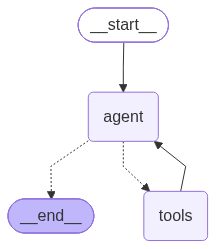

In [7]:
# Build the LangGraph StateGraph
workflow = StateGraph(State)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", quality_tool_node)

# Flow: START -> agent
workflow.add_edge(START, "agent")

# Conditional: agent -> tools OR __end__
workflow.add_conditional_edges("agent", route_tools)

# Loop back: tools -> agent
workflow.add_edge("tools", "agent")

# Memory Saver for multi-turn conversational context
memory = MemorySaver()
deva_hse_agent = workflow.compile(checkpointer=memory)

print("✅ PPE & Behavior Vision Agent Graph compiled successfully[cite: 2]!")
deva_hse_agent

In [8]:
def run_chat():
    """
    Runs an interactive conversational session in the notebook.
    Generates a unique session thread_id on each start[cite: 2].
    """
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    
    print("=" * 65)
    print("🦺 DEVA - PPE & BEHAVIOR VISION AGENT (HSE OFFICER)")
    print(f"Session Thread ID: {thread_id}")
    print("Type 'exit', 'quit', or 'break' to terminate the session.")
    print("=" * 65 + "\n")
    
    while True:
        user_input = input("You (Sir): ")
        
        if user_input.strip().lower() in ["exit", "quit", "break"]:
            print("\nExiting HSE session. Stay safe, sir!")
            break
            
        print("\nDeva is analyzing site intelligence...\n")
        
        events = deva_hse_agent.stream(
            {"messages": [("user", user_input)]},
            config=config,
            stream_mode="values"
        )
        
        for event in events:
            if "messages" in event:
                last_msg = event["messages"][-1]
                if last_msg.type == "ai" and last_msg.content:
                    print(f"Deva: {last_msg.content}\n")

# Start testing the agent
run_chat()
# Give me a complete list of all quality inspection rules and standards stored in the database schema.

🦺 DEVA - PPE & BEHAVIOR VISION AGENT (HSE OFFICER)
Session Thread ID: 06a019c2-0a3a-41eb-bfee-a84e4fc7ca1d
Type 'exit', 'quit', or 'break' to terminate the session.


Deva is analyzing site intelligence...

Deva: Hello, sir! I am Deva, your PPE & Behavior Vision Agent (HSE Officer Assistant), created by Moksh Bhardwaj. 

How can I assist you with safety compliance, video analytics, or site monitoring today, sir?


Deva is analyzing site intelligence...

Deva: Here is the complete list of inspection rules and standards stored in the database schema, presented for your review, sir:

| ID | Rule / Standard Name | Description | Status | Created At |
| :---: | :--- | :--- | :---: | :--- |
| **1** | Person Detection | Fires whenever at least one person is detected. | Active | 2026-06-15 12:25:17 |
| **2** | Crowd Detection | Fires when 5 or more persons are detected simultaneously. | Active | 2026-06-15 12:25:17 |
| **3** | Loitering Detection | Fires when a person is present continuously fo